# 04 — Single-Variable Composite Explorer

Interactive notebook for exploring **any** variable (or sum of variables)
from the composite-blocking NPZ archive.

**Two modes**:
1. **2-panel** (default): composite mean + bootstrap significance (hatched non-sig)
2. **6-panel** (`projection=True`): adds 2×2 projection onto dh−1 orthogonal basis
   (INT, PRP, DEF, Residual) using **only significant** grid points, with
   β, αx, αy, γ in the subtitle.

Data: `/net/flood/data2/users/x_yan/composite_blocking_tempest/onset`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan

## 1  Configuration & available fields

In [2]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
SMOOTH_DEG = 6.0
GRID_SP    = 1.5
N_BOOT     = 1000
ALPHA      = 0.05
SEED       = 42
PV_CONTOUR = -0.5e-6     # PV anomaly contour for mask boundary
N_CONTOUR  = 21          # number of contourf levels

# ── Discover available fields and levels from a sample NPZ ──
_sample = np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/" +
                  sorted(os.listdir(f"{DATA_ROOT}/{STAGE}/dh=+0"))[0])
levels_hpa = _sample["levels"]          # isobaric levels
wavg_levels = _sample["wavg_levels"]    # levels used for wavg

# Separate 2D (wavg) vs 3D fields
_all_keys = sorted(_sample.keys())
_meta = {"X_rel", "Y_rel", "levels", "wavg_levels", "center_lat", "center_lon",
         "center_mode", "dh", "lat0", "lat_vec", "lon0", "lon_vec_unwrapped",
         "track_id", "ts", "G0", "H_SCALE", "term"}
fields_wavg = sorted(k for k in _all_keys
                     if _sample[k].ndim == 2 and not k.endswith("_3d") and k not in _meta)
fields_3d   = sorted(k for k in _all_keys if k.endswith("_3d"))

print(f"Isobaric levels (hPa): {levels_hpa}")
print(f"Wavg levels   (hPa) : {wavg_levels}")
print(f"\n── 2D wavg fields ({len(fields_wavg)}) ──")
for f in fields_wavg:
    print(f"  {f}")
print(f"\n── 3D isobaric fields ({len(fields_3d)}) ──")
for f in fields_3d[:10]:
    print(f"  {f}")
print(f"  ... ({len(fields_3d)} total)")

del _sample

Isobaric levels (hPa): [1000  850  700  500  400  300  250  200  100]
Wavg levels   (hPa) : [300 250 200]

── 2D wavg fields (81) ──
  Q
  pv
  pv_anom
  pv_anom_dp
  pv_anom_dt
  pv_anom_dx
  pv_anom_dy
  pv_bar
  pv_bar_dp
  pv_bar_dt
  pv_bar_dx
  pv_bar_dy
  pv_dp
  pv_dx
  pv_dy
  t
  theta
  theta_dot
  theta_dt
  u
  u_anom
  u_anom_div
  u_anom_div_dry
  u_anom_div_moist
  u_anom_har
  u_anom_pv_anom_dx
  u_anom_pv_bar_dx
  u_anom_rot
  u_bar
  u_bar_pv_anom_dx
  u_bar_pv_bar_dx
  u_div_dry_pv_anom_dx
  u_div_dry_pv_bar_dx
  u_div_moist_pv_anom_dx
  u_div_moist_pv_bar_dx
  u_div_pv_anom_dx
  u_div_pv_bar_dx
  u_har_pv_anom_dx
  u_har_pv_bar_dx
  u_rot_pv_anom_dx
  u_rot_pv_bar_dx
  v
  v_anom
  v_anom_div
  v_anom_div_dry
  v_anom_div_moist
  v_anom_har
  v_anom_pv_anom_dy
  v_anom_pv_bar_dy
  v_anom_rot
  v_bar
  v_bar_pv_anom_dy
  v_bar_pv_bar_dy
  v_div_dry_pv_anom_dy
  v_div_dry_pv_bar_dy
  v_div_moist_pv_anom_dy
  v_div_moist_pv_bar_dy
  v_div_pv_anom_dy
  v_div_pv_bar_dy


## 2  Core helpers

In [3]:
from zipfile import BadZipFile

def _load_npz(path):
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None          # file still being written or corrupt


def load_events(dh, stage=STAGE):
    """Load all events at a given dh → list[dict] (skips bad files)."""
    sign = "+" if dh >= 0 else ""
    d = f"{DATA_ROOT}/{stage}/dh={sign}{dh}"
    files = sorted(glob.glob(os.path.join(d, "track_*.npz")))
    if not files:
        return []
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(_load_npz, files))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ dh={dh}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good


def get_field(event, var_spec, level="wavg"):
    """Extract a 2-D field from one event dict.

    var_spec : str or list[str]
        Each string is a field name, optionally prefixed with '-' for negation.
        Multiple fields are summed.  Examples:
            "-u_bar_pv_anom_dx"        → negated single field
            ["-u_bar_pv_anom_dx",
             "-v_bar_pv_anom_dy"]      → negated sum of two fields
    level : 'wavg' or int (hPa)
        'wavg' uses the pre-computed 2-D wavg field.
        An int selects from the _3d array at that pressure level.
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    total = None
    for vs in var_spec:
        negate = vs.startswith("-")
        name = vs.lstrip("-").strip()

        if isinstance(level, str) and level.lower() == "wavg":
            arr = event[name]                       # already 2-D
        else:
            key_3d = name if name.endswith("_3d") else name + "_3d"
            arr_3d = event[key_3d]
            lvls = event["levels"]
            idx = int(np.argmin(np.abs(lvls - float(level))))
            arr = arr_3d[idx]

        if negate:
            arr = -arr
        total = arr.copy() if total is None else total + arr

    return total


def bootstrap_sig(events, var_spec, level="wavg",
                  n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """Compute composite mean + bootstrap significance mask.

    Returns (mean_2d, sig_mask)  —  sig_mask=True where CI excludes zero.
    """
    stack = np.array([get_field(e, var_spec, level) for e in events])  # (N, Y, X)
    N = stack.shape[0]
    rng = np.random.default_rng(seed)

    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)

    lo = np.percentile(boot, 100 * alpha / 2, axis=0)
    hi = np.percentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask


print("Helpers defined.")

Helpers defined.


## 3  Main plotting function

In [4]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)


def plot_var(var_spec, dh=0, level="wavg", projection=False,
             n_boot=N_BOOT, alpha=ALPHA, seed=SEED, figsize_scale=1.0):
    """Composite + bootstrap plot for any variable(s).

    Parameters
    ----------
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
    dh : int
        Lifecycle hour.
    level : 'wavg' or int
        Pressure level or 'wavg'.
    projection : bool
        If True, add 2×2 projection rows (3-row figure).
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    # ── 1. Load events ──
    evs = load_events(dh)
    N = len(evs)
    if N == 0:
        print(f"No events at dh={dh}")
        return
    X_rel = evs[0]["X_rel"]
    Y_rel = evs[0]["Y_rel"]
    x_rel = X_rel[0, :]
    y_rel = Y_rel[:, 0]

    # ── 2. Composite mean + bootstrap ──
    print(f"Computing bootstrap (N={N}, n_boot={n_boot}) ...")
    mean_fld, sig_mask = bootstrap_sig(evs, var_spec, level, n_boot, alpha, seed)
    pct_sig = 100 * np.mean(sig_mask)
    print(f"  {pct_sig:.1f}% significant at {100*(1-alpha):.0f}%")

    # PV anomaly composite for contour
    pv_anom_mean = np.mean([e["pv_anom"] for e in evs], axis=0)

    # ── Label construction ──
    var_label = " + ".join(var_spec)
    level_str = "wavg" if isinstance(level, str) else f"{level} hPa"

    # ── 3. Projection (if requested) ──
    proj = None
    if projection:
        # Basis from dh-1 composite
        dh_basis = max(dh - 1, -13)
        evs_b = load_events(dh_basis) if dh_basis != dh else evs
        pv_b = np.mean([e["pv_anom"] for e in evs_b], axis=0)
        dx_b = np.mean([e["pv_anom_dx"] for e in evs_b], axis=0)
        dy_b = np.mean([e["pv_anom_dy"] for e in evs_b], axis=0)

        basis = compute_orthogonal_basis(
            pv_b, dx_b, dy_b, x_rel, y_rel,
            mask_negative=True,
            apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
        )

        # Project sig-only field
        field_sig = np.where(sig_mask, mean_fld, 0.0)
        field_sig_s = smooth(field_sig)
        proj = project_field(field_sig_s, basis)
        print(f"  Projection (sig-only): "
              f"β={proj['beta']:.3e}  αx={proj['ax']:.3f}  "
              f"αy={proj['ay']:.3f}  γ={proj['gamma']:.3e}")

    # ── 4. Plot ──
    n_rows = 3 if projection else 1
    fig = plt.figure(figsize=(14 * figsize_scale, 5 * n_rows * figsize_scale))
    gs = GridSpec(n_rows, 2, figure=fig, hspace=0.35, wspace=0.25)

    # Colour scale
    vmax = np.nanpercentile(np.abs(mean_fld), 95)
    vmax = max(vmax, 1e-30)
    clevels = np.linspace(-vmax, vmax, N_CONTOUR)

    # --- Row 1, Left: Composite mean ---
    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                       cmap="RdBu_r", extend="both")
    ax0.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax0.set_title(f"Composite Mean  (N={N})", fontsize=11, fontweight="bold")
    ax0.set_ylabel("Y (deg)"); ax0.set_xlabel("X (deg)")
    ax0.set_aspect("equal")
    plt.colorbar(im0, ax=ax0, shrink=0.85)

    # --- Row 1, Right: Bootstrap significance ---
    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                       cmap="RdBu_r", extend="both")
    ax1.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    # Hatch non-significant regions
    ax1.contourf(X_rel, Y_rel, (~sig_mask).astype(float),
                 levels=[0.5, 1.5], hatches=["xxx"], colors="none", zorder=5)
    ax1.set_title(f"Bootstrap sig ({100*(1-alpha):.0f}%)  "
                  f"Hatch=n.s.  ({pct_sig:.0f}% sig)",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("X (deg)")
    ax1.set_aspect("equal")
    plt.colorbar(im1, ax=ax1, shrink=0.85)

    # --- Rows 2-3: Projection (2×2) ---
    if projection and proj is not None:
        panels = [
            ("INT (β · Φ₁)",           proj["int"]),
            ("PRP (αx·Φ₂ + αy·Φ₃)",   proj["prop"]),
            ("DEF (γ · Φ₄)",           proj["def"]),
            ("Residual",               proj["resid"]),
        ]
        # Colour scale for projection panels
        all_abs = np.concatenate([
            np.abs(p[np.isfinite(p)]) for _, p in panels if np.any(np.isfinite(p))
        ])
        vmax_p = float(np.percentile(all_abs, 95)) if all_abs.size else 1e-30
        vmax_p = max(vmax_p, 1e-30)
        clev_p = np.linspace(-vmax_p, vmax_p, N_CONTOUR)

        coef_txt = (f"β={proj['beta']:.3e} s⁻¹   "
                    f"αx={proj['ax']:.3f} m/s   "
                    f"αy={proj['ay']:.3f} m/s   "
                    f"γ={proj['gamma']:.3e} s⁻¹   "
                    f"RMSE/max={proj['rmse']/(np.nanmax(np.abs(mean_fld))+1e-30):.3f}")

        for idx, (label, field) in enumerate(panels):
            row = 1 + idx // 2
            col = idx % 2
            ax = fig.add_subplot(gs[row, col])
            im = ax.contourf(X_rel, Y_rel, field, levels=clev_p,
                             cmap="RdBu_r", extend="both")
            ax.contour(X_rel, Y_rel, pv_anom_mean,
                       levels=[PV_CONTOUR], colors="white", linewidths=2.0)
            ax.set_title(label, fontsize=10, fontweight="bold")
            ax.set_xlabel("X (deg)")
            if col == 0:
                ax.set_ylabel("Y (deg)")
            ax.set_aspect("equal")
            plt.colorbar(im, ax=ax, shrink=0.75)

        # Coefficient annotation between rows 1 and 2
        fig.text(0.5, 1 - 1.0 / n_rows - 0.01, coef_txt,
                 ha="center", fontsize=10, fontstyle="italic",
                 transform=fig.transFigure)

    sign_str = "+" if dh >= 0 else ""
    fig.suptitle(
        f"{STAGE}  dh={sign_str}{dh}   Level={level_str}   N={N}\n"
        f"Field: {var_label}",
        fontsize=12, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    plt.show()
    return proj


print("plot_var() defined.")

plot_var() defined.


## 4  Examples

Computing bootstrap (N=1134, n_boot=1000) ...
  61.9% significant at 95%


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


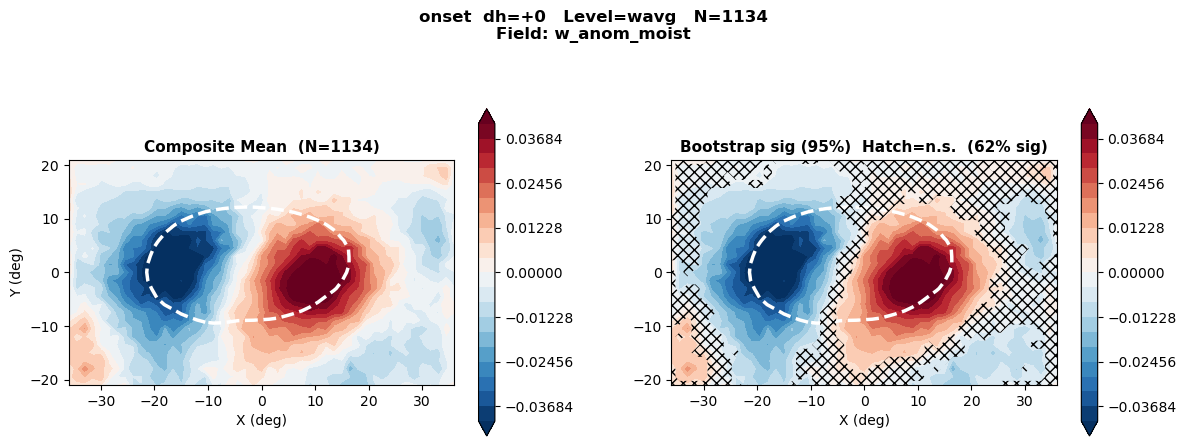

In [5]:
plot_var(["w_anom_moist"], dh=0, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  58.6% significant at 95%


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


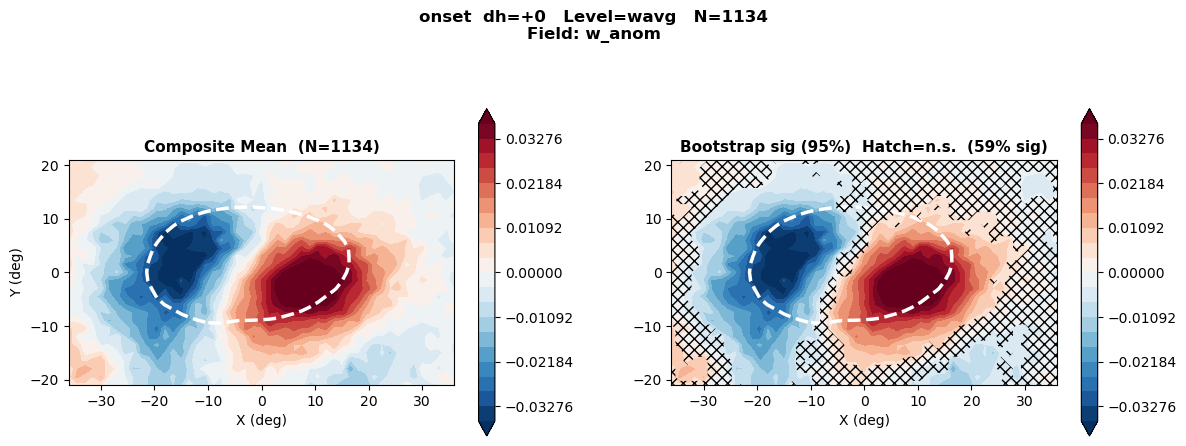

In [6]:
plot_var(["w_anom"], dh=0, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  48.6% significant at 95%


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


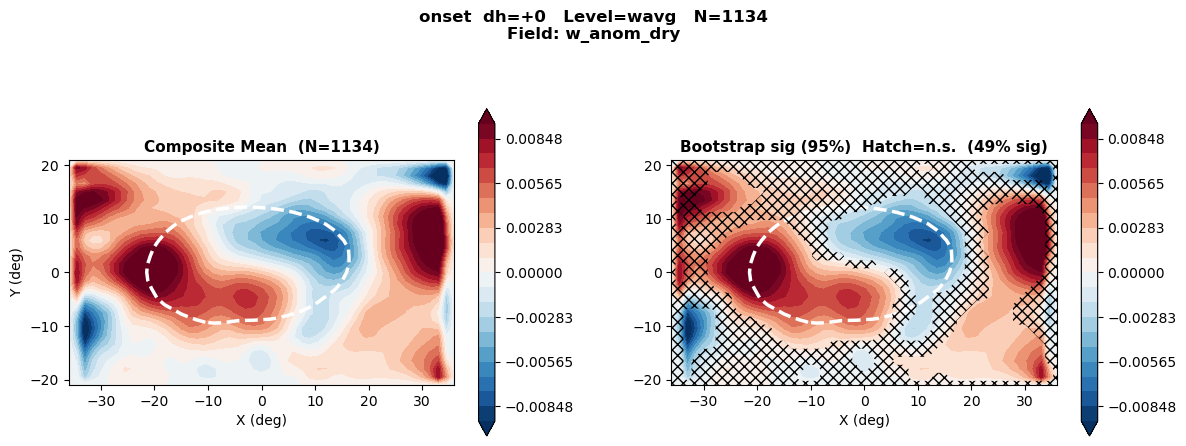

In [7]:
plot_var(["w_anom_dry"], dh=0, projection = False)

Computing bootstrap (N=1134, n_boot=1000) ...
  37.9% significant at 95%


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


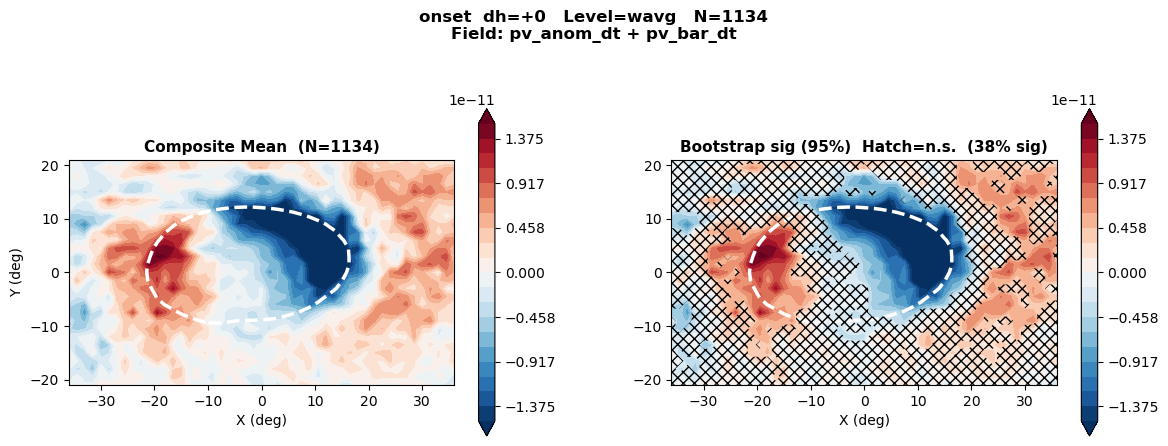

In [8]:
# 2-panel: total tendency dq/dt (no projection)
plot_var(["pv_anom_dt", "pv_bar_dt"], dh=0, projection=False)

Computing bootstrap (N=1134, n_boot=1000) ...
  63.8% significant at 95%
  Projection (sig-only): β=-3.558e-09  αx=17.446  αy=-0.308  γ=-2.812e+06


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


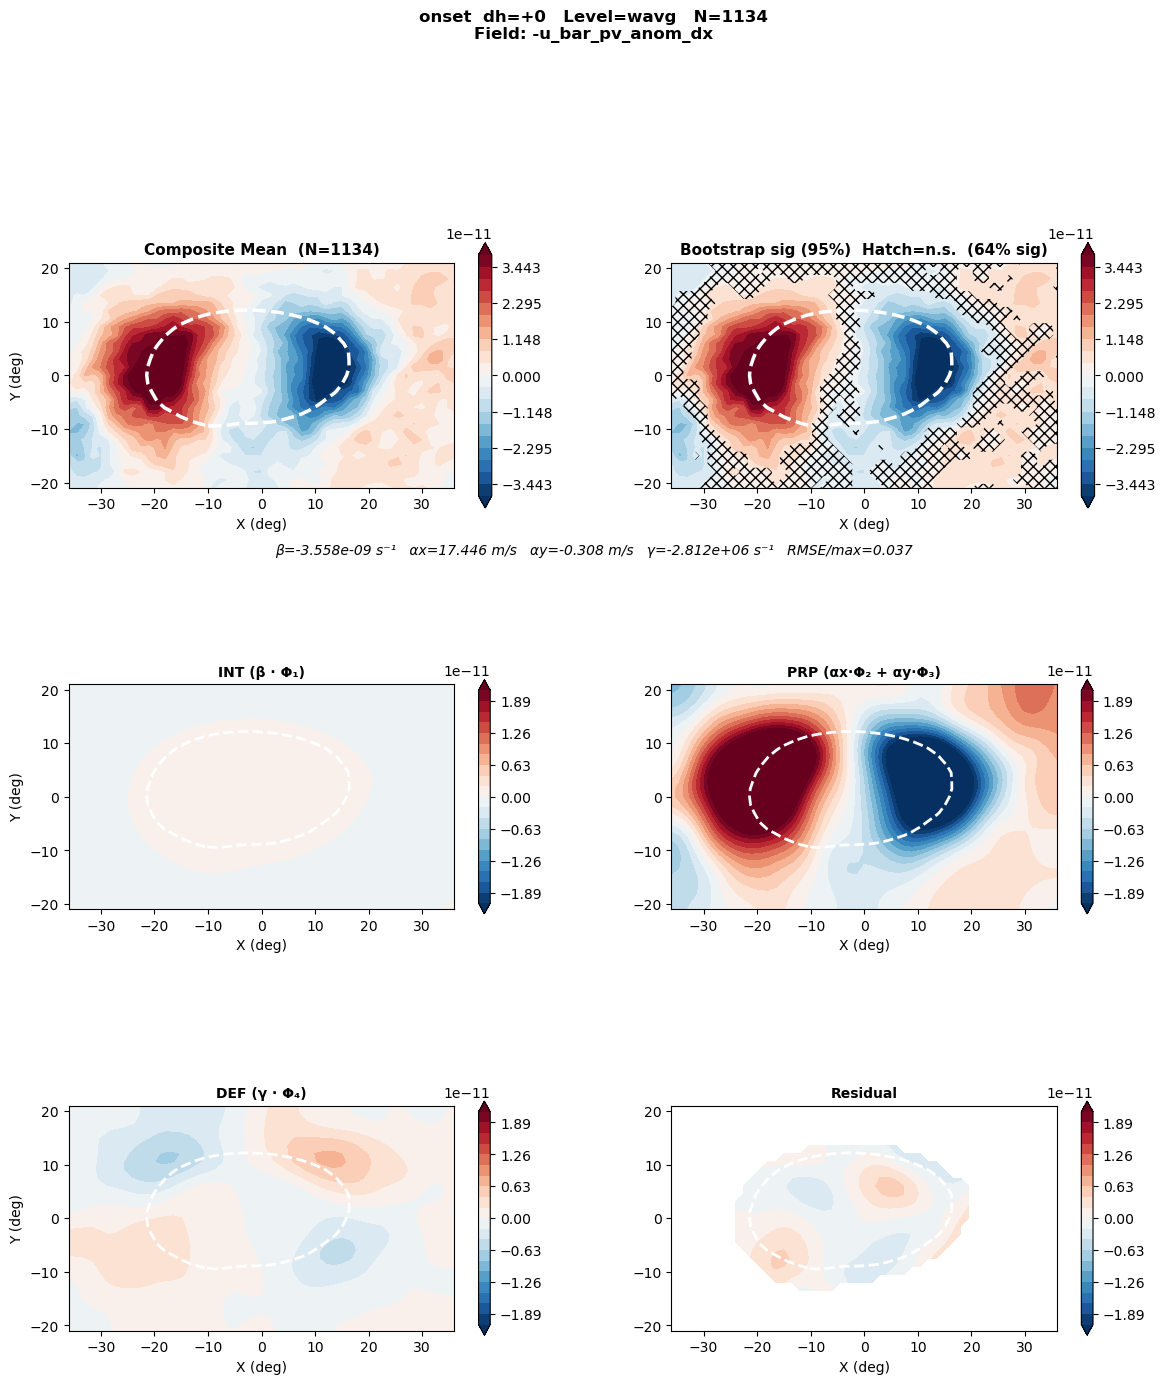

{'beta': -3.55769916645488e-09,
 'ax': 17.446470763718533,
 'ay': -0.30787007120987325,
 'gamma': -2811934.173140983,
 'gamma_km2': -2.8119341731409833,
 'beta_raw': -3.55769916645488e-15,
 'ax_raw': 1.7446470763718534e-11,
 'ay_raw': -3.0787007120987325e-13,
 'gamma_raw': -2.811934173140983e-12,
 'prop': array([[-4.57473537e-12, -4.47273493e-12, -4.17561121e-12, ...,
          3.39332172e-13, -1.43780938e-13, -4.26759107e-13],
        [-4.84776222e-12, -4.77900602e-12, -4.51805335e-12, ...,
          6.33359559e-13,  2.10726256e-13, -3.60945132e-14],
        [-5.27219527e-12, -5.22710138e-12, -4.98650279e-12, ...,
          1.18863802e-12,  8.77990598e-13,  6.97514010e-13],
        ...,
        [-7.67483130e-12, -7.25297354e-12, -6.32539445e-12, ...,
          1.12456812e-11,  1.04379109e-11,  9.83509702e-12],
        [-8.60566190e-12, -8.18297097e-12, -7.28104248e-12, ...,
          1.13785537e-11,  1.06890095e-11,  1.01621209e-11],
        [-9.14433293e-12, -8.68685122e-12, -7.74556

In [9]:
# 6-panel: mean-wind advection with projection
plot_var(["-u_bar_pv_anom_dx"], dh=0, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  82.5% significant at 95%
  Projection (sig-only): β=6.151e-07  αx=-8.036  αy=0.255  γ=1.810e+06


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


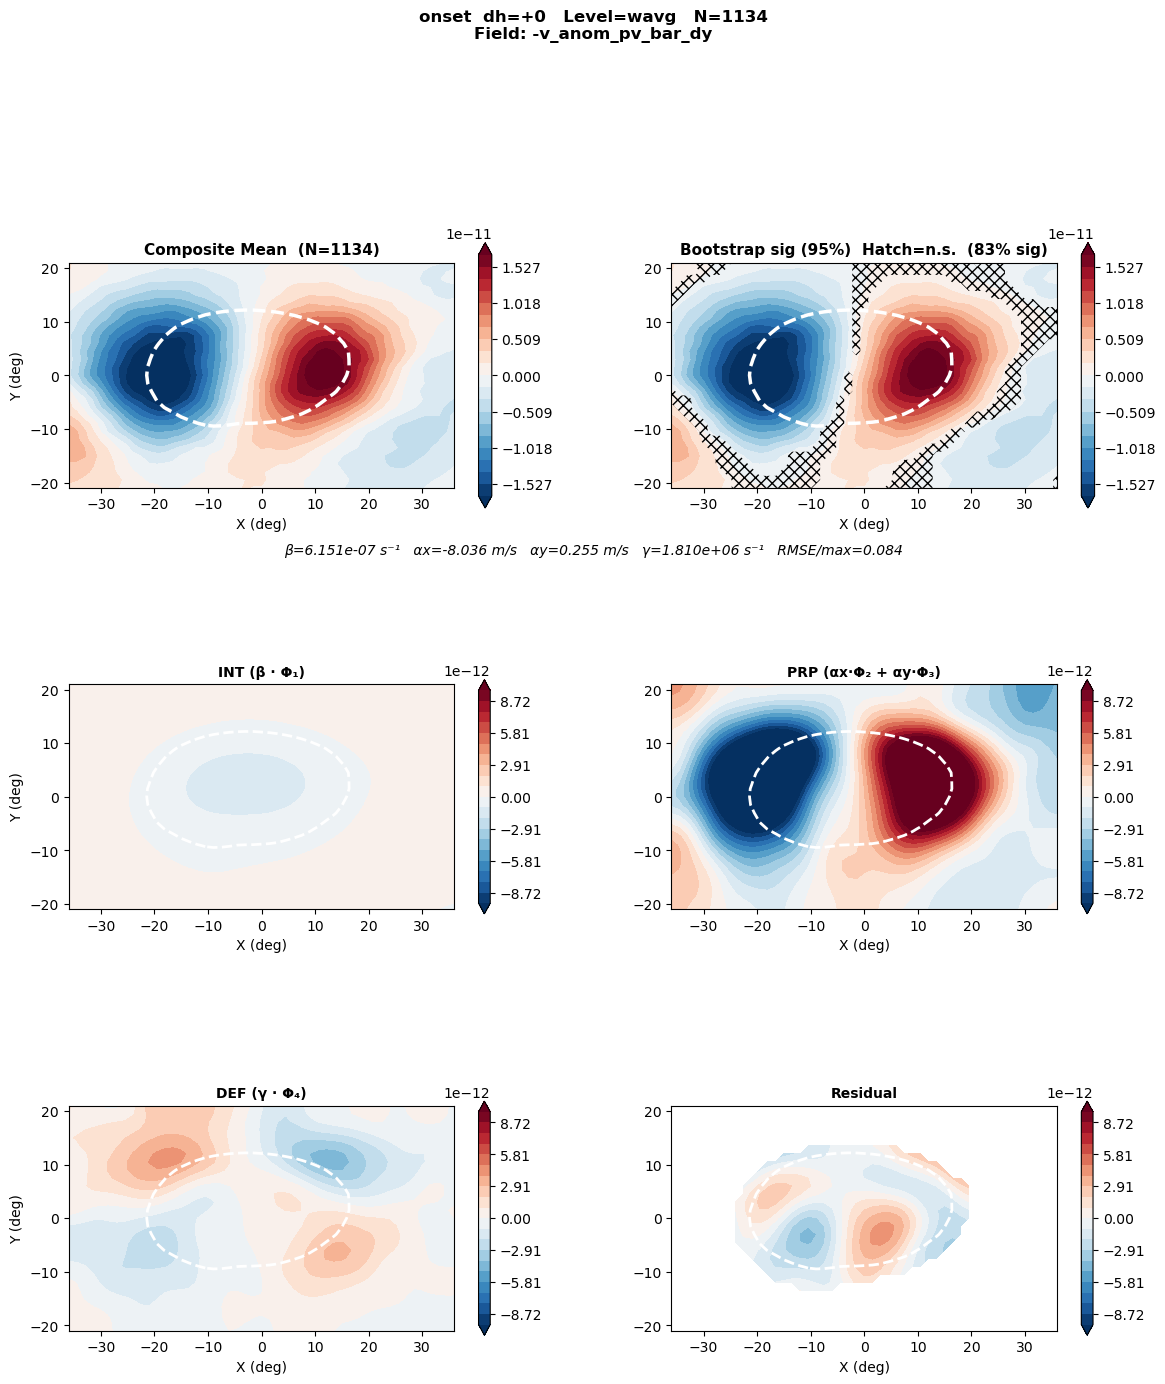

{'beta': 6.151070835450329e-07,
 'ax': -8.03588992888385,
 'ay': 0.25503213037725697,
 'gamma': 1809996.6480152986,
 'gamma_km2': 1.8099966480152987,
 'beta_raw': 6.151070835450329e-13,
 'ax_raw': -8.035889928883851e-12,
 'ay_raw': 2.55032130377257e-13,
 'gamma_raw': 1.8099966480152987e-12,
 'prop': array([[ 2.07730671e-12,  2.02780713e-12,  1.88667693e-12, ...,
         -1.66589953e-13,  5.68524816e-14,  1.87784794e-13],
        [ 2.20370404e-12,  2.16988921e-12,  2.04611162e-12, ...,
         -3.02016269e-13, -1.05876446e-13,  8.78618175e-15],
        [ 2.39984791e-12,  2.37759955e-12,  2.26443999e-12, ...,
         -5.57859347e-13, -4.12734770e-13, -3.28239878e-13],
        ...,
        [ 3.59368324e-12,  3.39872289e-12,  2.97035601e-12, ...,
         -5.18504103e-12, -4.81522730e-12, -4.53882541e-12],
        [ 4.02390483e-12,  3.82920754e-12,  3.41391430e-12, ...,
         -5.24512590e-12, -4.93117494e-12, -4.69046902e-12],
        [ 4.27094264e-12,  4.06061842e-12,  3.62798387e-1

In [10]:
# 6-panel: planetary vorticity advection
plot_var(["-v_anom_pv_bar_dy"], dh=0, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  26.3% significant at 95%
  Projection (sig-only): β=-2.181e-07  αx=0.100  αy=-0.486  γ=-3.587e+05


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


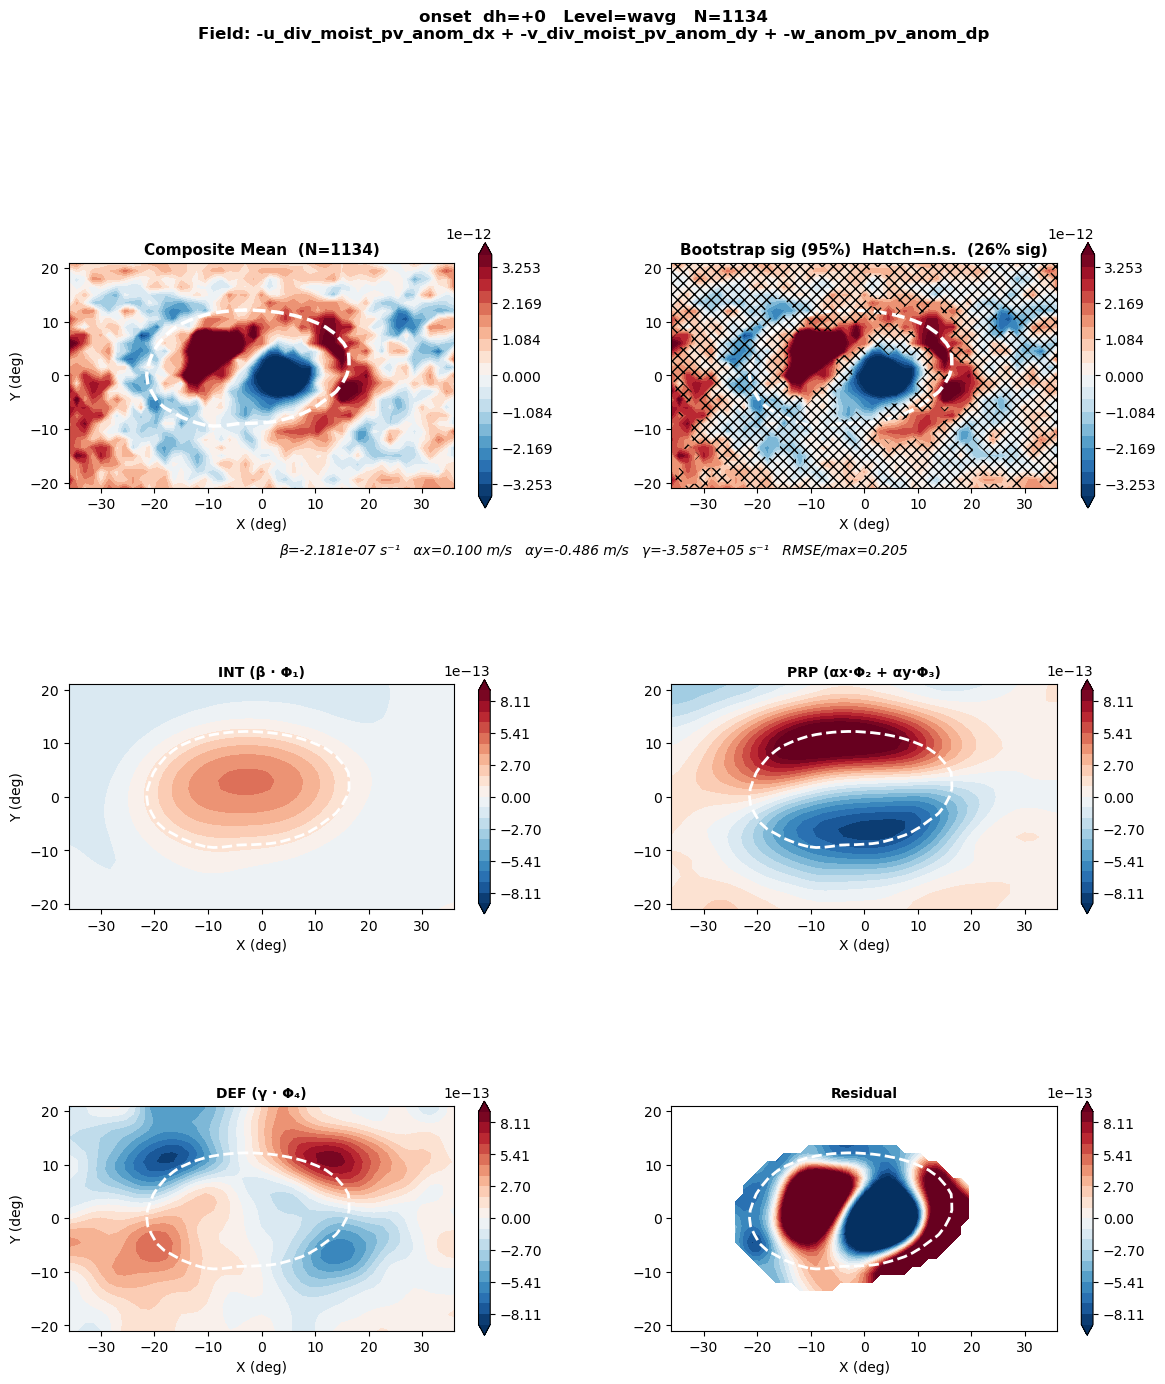

{'beta': -2.1805156020540556e-07,
 'ax': 0.10014715089949441,
 'ay': -0.4863097517525401,
 'gamma': -358716.43745103414,
 'gamma_km2': -0.35871643745103415,
 'beta_raw': -2.1805156020540556e-13,
 'ax_raw': 1.0014715089949441e-13,
 'ay_raw': -4.863097517525401e-13,
 'gamma_raw': -3.5871643745103415e-13,
 'prop': array([[ 1.01387623e-13,  1.12748309e-13,  1.32745126e-13, ...,
          4.59944470e-14,  3.92872894e-14,  3.51302400e-14],
        [ 9.70796315e-14,  1.06655999e-13,  1.23483262e-13, ...,
          4.76674089e-14,  3.89342927e-14,  3.33393262e-14],
        [ 9.18663922e-14,  9.84501821e-14,  1.09841772e-13, ...,
          5.11987901e-14,  4.06874505e-14,  3.38019161e-14],
        ...,
        [-2.94982881e-13, -2.89772989e-13, -2.79648934e-13, ...,
          8.70240776e-14,  9.20045832e-14,  9.39182351e-14],
        [-3.06653556e-13, -3.04206909e-13, -2.99617497e-13, ...,
          8.30086425e-14,  9.46912503e-14,  1.00141456e-13],
        [-3.05143304e-13, -3.04199248e-13, -3

In [11]:
# 6-panel: moist-divergent + vertical eddy-eddy
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy",
          "-w_anom_pv_anom_dp"], dh=0, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  66.7% significant at 95%
  Projection (sig-only): β=1.487e-06  αx=-0.594  αy=-0.191  γ=8.079e+04


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


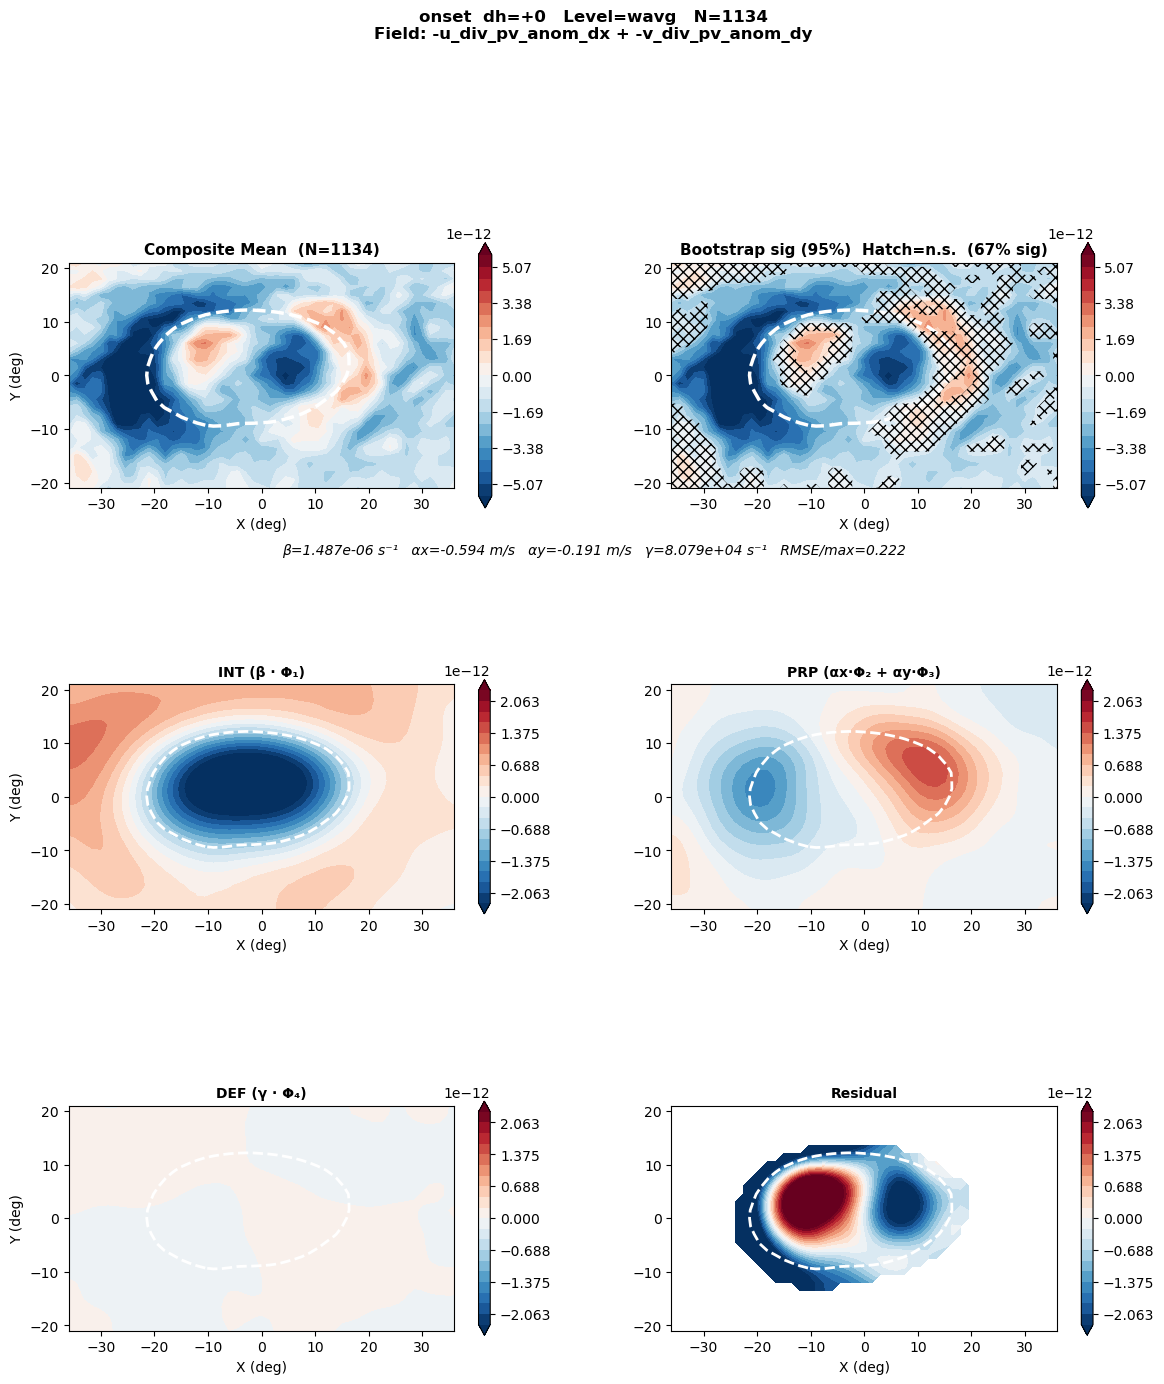

{'beta': 1.4869539413838796e-06,
 'ax': -0.59409946485364,
 'ay': -0.19090561189162245,
 'gamma': 80792.12358506353,
 'gamma_km2': 0.08079212358506353,
 'beta_raw': 1.4869539413838796e-12,
 'ax_raw': -5.9409946485364e-13,
 'ay_raw': -1.9090561189162245e-13,
 'gamma_raw': 8.079212358506353e-14,
 'prop': array([[ 2.08836079e-13,  2.09841154e-13,  2.07325645e-13, ...,
          6.75181984e-15,  2.15680600e-14,  3.01515772e-14],
        [ 2.16994250e-13,  2.18469082e-13,  2.15954237e-13, ...,
         -3.26677068e-15,  8.50363031e-15,  1.51719871e-14],
        [ 2.30293190e-13,  2.31386443e-13,  2.27354052e-13, ...,
         -2.20325503e-14, -1.50818276e-14, -1.13673501e-14],
        ...,
        [ 1.57056289e-13,  1.43849797e-13,  1.14258036e-13, ...,
         -3.73606239e-13, -3.42102257e-13, -3.19341248e-13],
        [ 1.86123711e-13,  1.71738378e-13,  1.40780934e-13, ...,
         -3.80116842e-13, -3.50135260e-13, -3.28670967e-13],
        [ 2.06379784e-13,  1.90102208e-13,  1.56407921

In [12]:
# 6-panel: divergent outflow (no projection)
plot_var(["-u_div_pv_anom_dx", "-v_div_pv_anom_dy"], dh=0, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  20.0% significant at 95%
  Projection (sig-only): β=1.266e-06  αx=0.867  αy=0.859  γ=-3.221e+05


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


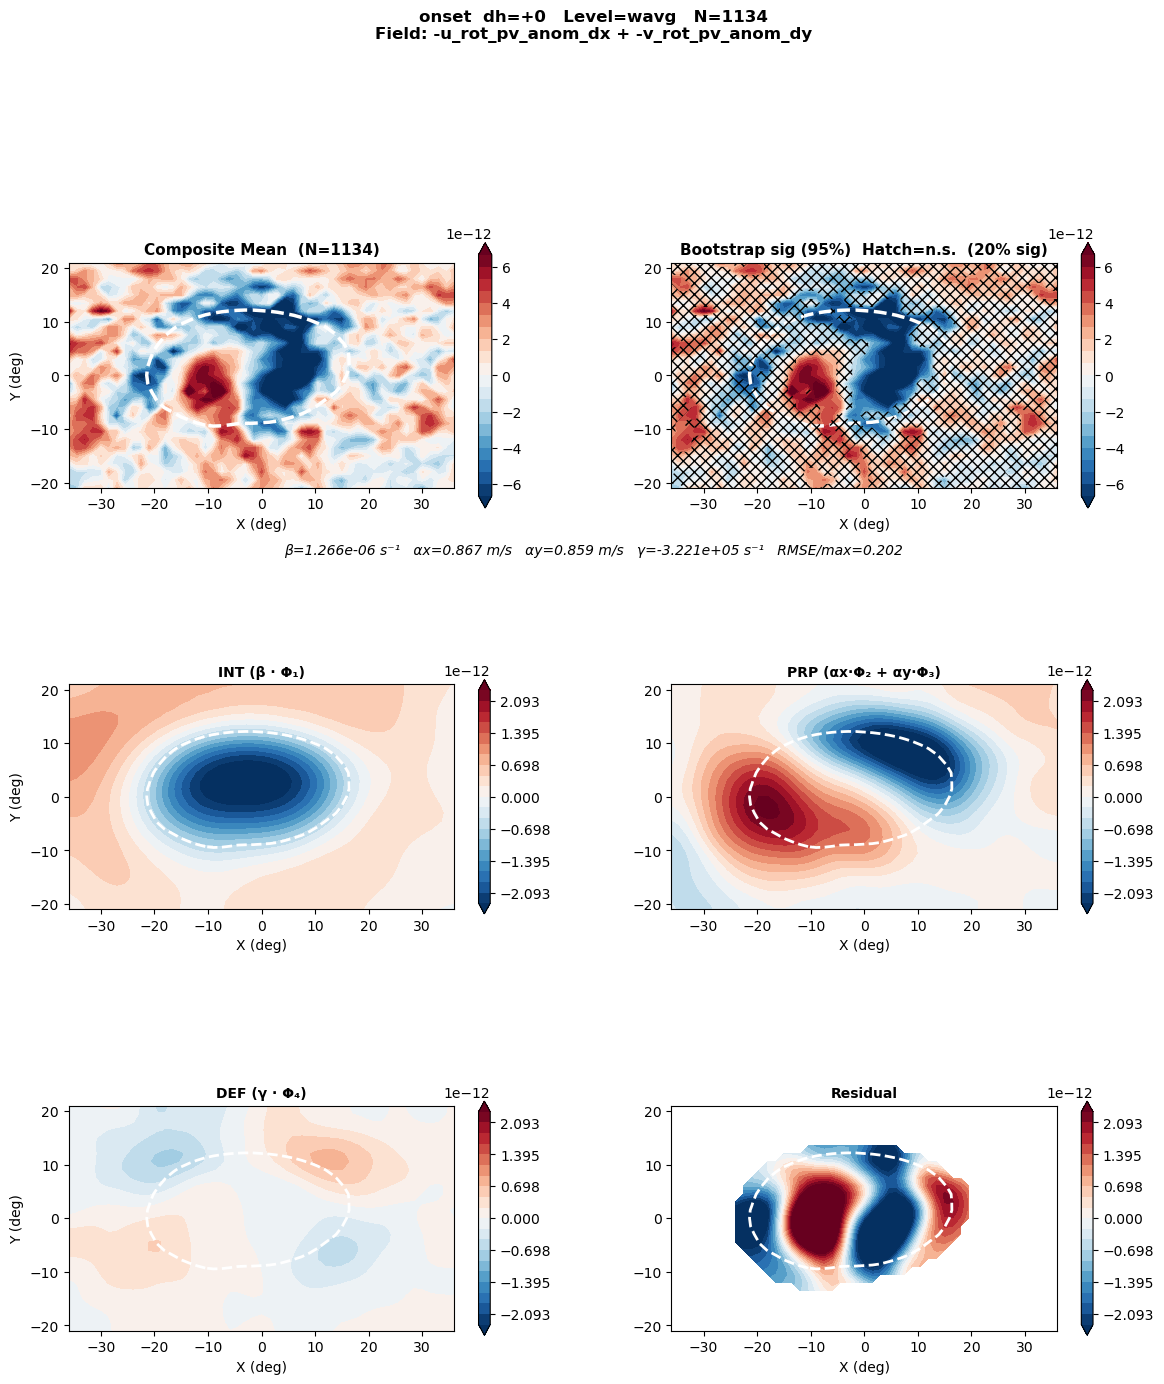

{'beta': 1.2663538670925694e-06,
 'ax': 0.8672535861111843,
 'ay': 0.8586066576095038,
 'gamma': -322091.54143416265,
 'gamma_km2': -0.32209154143416263,
 'beta_raw': 1.2663538670925693e-12,
 'ax_raw': 8.672535861111843e-13,
 'ay_raw': 8.586066576095039e-13,
 'gamma_raw': -3.2209154143416265e-13,
 'prop': array([[-4.57630171e-13, -4.71993677e-13, -4.90213553e-13, ...,
         -6.25735160e-14, -7.94935596e-14, -8.89923400e-14],
        [-4.66259017e-13, -4.79401091e-13, -4.94076946e-13, ...,
         -4.79308448e-14, -5.75643497e-14, -6.22980328e-14],
        [-4.82348995e-13, -4.91514933e-13, -4.97609637e-13, ...,
         -2.09486136e-14, -2.06488111e-14, -1.90700624e-14],
        ...,
        [ 7.10561609e-14,  8.69974976e-14,  1.24450590e-13, ...,
          5.18487788e-13,  4.60988434e-13,  4.21330562e-13],
        [ 3.61972267e-14,  5.71723362e-14,  1.03066958e-13, ...,
          5.33710582e-13,  4.71224398e-13,  4.29748329e-13],
        [ 1.11949336e-15,  2.68942632e-14,  8.08061

In [13]:
# 6-panel: rotational eddy advection
plot_var(["-u_rot_pv_anom_dx", "-v_rot_pv_anom_dy"], dh=0, projection=True)

Computing bootstrap (N=1134, n_boot=1000) ...
  25.7% significant at 95%
  Projection (sig-only): β=-4.285e-07  αx=-0.399  αy=-0.001  γ=8.693e+04


/tmp/ipykernel_339672/1967243502.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


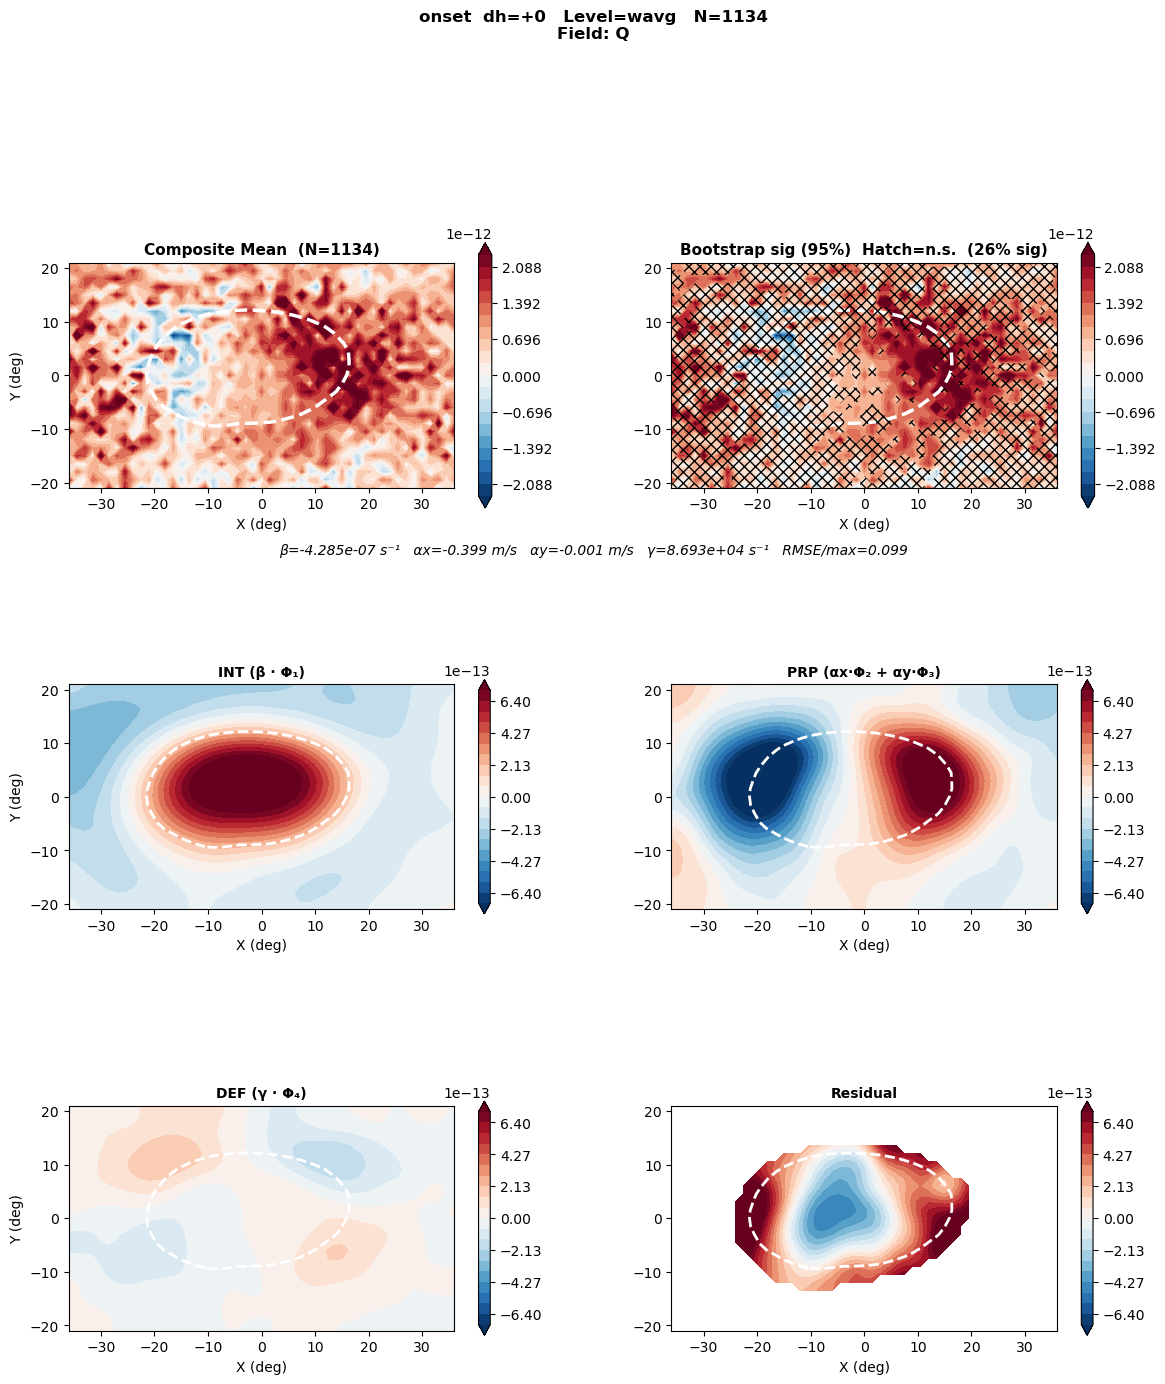

{'beta': -4.2853357210297525e-07,
 'ax': -0.3988354307414585,
 'ay': -0.000923281993567662,
 'gamma': 86930.22697614864,
 'gamma_km2': 0.08693022697614863,
 'beta_raw': -4.2853357210297523e-13,
 'ax_raw': -3.988354307414585e-13,
 'ay_raw': -9.23281993567662e-16,
 'gamma_raw': 8.693022697614864e-14,
 'prop': array([[ 1.06678176e-13,  1.04523436e-13,  9.80315698e-14, ...,
         -7.03359604e-15,  3.94598423e-15,  1.03733993e-14],
        [ 1.12874680e-13,  1.11453738e-13,  1.05740095e-13, ...,
         -1.37554593e-14, -4.19747104e-15,  1.37633081e-15],
        [ 1.22531815e-13,  1.21604868e-13,  1.16269138e-13, ...,
         -2.64437636e-14, -1.94856105e-14, -1.54559335e-14],
        ...,
        [ 1.71327748e-13,  1.61729673e-13,  1.40603590e-13, ...,
         -2.56712929e-13, -2.38088861e-13, -2.24219923e-13],
        [ 1.92503057e-13,  1.82840455e-13,  1.62212240e-13, ...,
         -2.59828972e-13, -2.43808644e-13, -2.31624451e-13],
        [ 2.04892978e-13,  1.94407070e-13,  1.728

In [14]:
# 6-panel: diabatic Q
plot_var(["Q"], dh=0, projection=True)

## Summary

- `plot_var(var_spec, dh, level, projection)` is the main entry point.
- `var_spec` accepts strings with `-` prefix for negation; lists are summed.
- `level='wavg'` uses pre-computed wavg; `level=200` extracts from 3D.
- `projection=True` adds a 2×2 panel showing INT/PRP/DEF/Residual
  from the dh−1 orthogonal basis, using **only bootstrapped-significant**
  grid points.
- White contour marks PV anomaly = −0.5×10⁻⁶ PVU (mask boundary).